In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [ ]:
df = pd.read_csv("/content/loan approval p.csv")


In [ ]:
df.head()


,income,credit_score,loan_amount,years_employed
0,57450.712295,714.832428,31194.843493,6.556722
1,47926.035482,783.659165,27397.069463,3.897629
2,59715.328072,552.100270,20477.042959,3.363602
3,72845.447846,689.407847,14824.505778,4.993251
4,46487.699379,604.455020,25585.786509,4.659631


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   income          500 non-null    float64
 1   credit_score    500 non-null    float64
 2   loan_amount     500 non-null    float64
 3   years_employed  500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [ ]:
print(df.isnull().sum())


income            0
credit_score      0
loan_amount       0
years_employed    0
dtype: int64


In [ ]:
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nNull values after handling:")
print(df.isnull().sum())



Null values after handling:
income            0
credit_score      0
loan_amount       0
years_employed    0
dtype: int64


In [ ]:
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    outlier_summary = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        below_count = (df_clean[col] < lower_bound).sum()
        above_count = (df_clean[col] > upper_bound).sum()

        outlier_summary[col] = {
            "below_lower_fence": below_count,
            "above_upper_fence": above_count,
            "total_outliers": below_count + above_count
        }

        # Remove outliers
        df_clean = df_clean[
            (df_clean[col] <= lower_bound) &
            (df_clean[col] >= upper_bound)
        ]

    # Print summary
    print("\nOutlier Summary:")
    for col, counts in outlier_summary.items():
        print(
            f"{col} → Below: {counts['below_lower_fence']}, "
            f"Above: {counts['above_upper_fence']}, "
            f"Total: {counts['total_outliers']}"
        )

    return df_clean


In [ ]:
df["approved"] = (
    (df["income"] > 40000) &
    (df["credit_score"] > 620) &
    (df["loan_amount"] < 30000)
).astype(int)

X = df.drop("approved", axis=1)
y = df["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

Decision Tree Accuracy: 0.992
Random Forest Accuracy: 0.992
Gradient Boosting Accuracy: 0.992


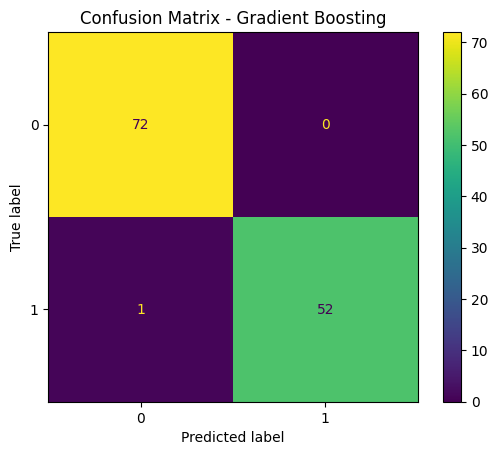

In [ ]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.3f}")

best_model = gb
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


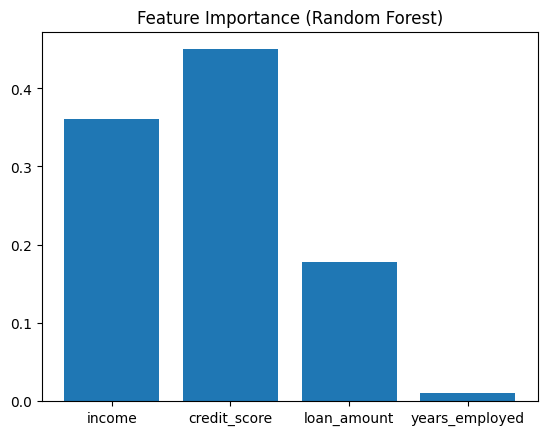

In [ ]:
importances = rf.feature_importances_
plt.bar(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


In [ ]:
import gradio as gr
import numpy as np

# Use trained Gradient Boosting model (gb)

def predict_loan(income, credit_score, loan_amount, years_employed):
    features = np.array([[income, credit_score, loan_amount, years_employed]])
    prediction = gb.predict(features)[0]

    if prediction == 1:
        return "✅ Loan Approved"
    else:
        return "❌ Loan Not Approved"

interface = gr.Interface(
    fn=predict_loan,
    inputs=[
        gr.Number(label="Income"),
        gr.Number(label="Credit Score"),
        gr.Number(label="Loan Amount"),
        gr.Number(label="Years Employed")
    ],
    outputs="text",
    title="Loan Approval Predictor",
    description="Enter applicant details to predict loan approval"
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d3f6a5ae14d7c3fb8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
